In [25]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame

df



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [26]:

df.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width',
    'target': 'species'
}, inplace=True)


In [27]:

df['species'] = df['species'].map(dict(enumerate(iris.target_names)))
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1.Descriptive Statistics (Sepal Length)

In [32]:

sepal_stats = df.groupby('species')['sepal_length'].agg(
    mean='mean',
    median='median',
    std='std'
)
sepal_stats


,mean,median,std
species,,,
setosa,5.006,5.0,0.352490
versicolor,5.936,5.9,0.516171
virginica,6.588,6.5,0.635880



**Interpretation:**  
Virginica has the highest variability in sepal length.


## 3. Central Tendency & Dispersion (Petal Length)

In [36]:
df.groupby('species')['petal_length'].agg(
    mean='mean',
    median='median',
    mode=lambda x: x.mode().iloc[0],
    variance='var',
    std_dev='std'
)


,mean,median,mode,variance,std_dev
species,,,,,
setosa,1.462,1.50,1.4,0.030159,0.173664
versicolor,4.260,4.35,4.5,0.220816,0.469911
virginica,5.552,5.55,5.1,0.304588,0.551895



The median differs from the mean when data is skewed or contains outliers.


## 4. Visualization

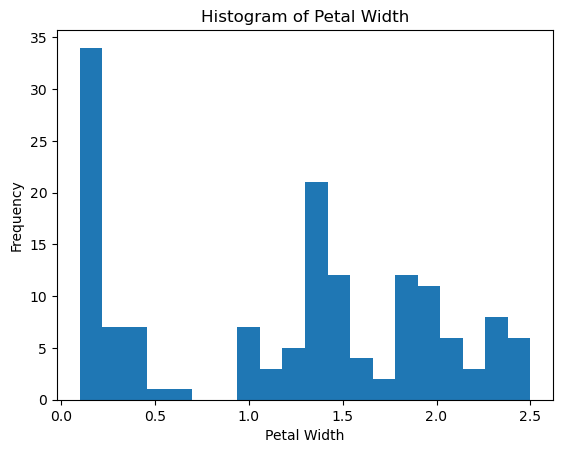

In [37]:

plt.figure()
plt.hist(df['petal_width'], bins=20)
plt.title("Histogram of Petal Width")
plt.xlabel("Petal Width")
plt.ylabel("Frequency")
plt.show()


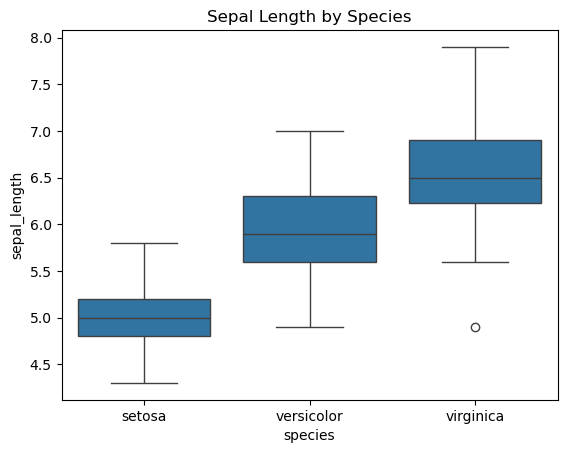

In [38]:

plt.figure()
sns.boxplot(x='species', y='sepal_length', data=df)
plt.title("Sepal Length by Species")
plt.show()



The boxplot better shows differences between species.


## 5. Skewness (Petal Length)

In [46]:

df.groupby('species')['petal_length'].skew()


species
setosa        0.106394
versicolor   -0.606508
virginica     0.549445
Name: petal_length, dtype: float64

## 6. Sampling & Central Limit Theorem

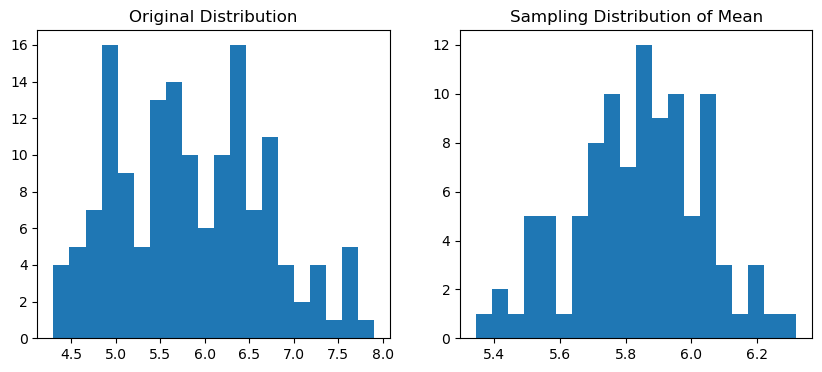

In [47]:

np.random.seed(42)
population = df['sepal_length']
sample_means = []

for _ in range(100):
    sample = np.random.choice(population, size=20)
    sample_means.append(sample.mean())

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(population, bins=20)
plt.title("Original Distribution")

plt.subplot(1,2,2)
plt.hist(sample_means, bins=20)
plt.title("Sampling Distribution of Mean")

plt.show()



Sample means form a more normal distribution, demonstrating CLT.


## 7. Correlation Analysis

In [48]:

r, p = stats.pearsonr(df['sepal_length'], df['petal_length'])
r, p


(0.8717537758865832, 1.0386674194497525e-47)

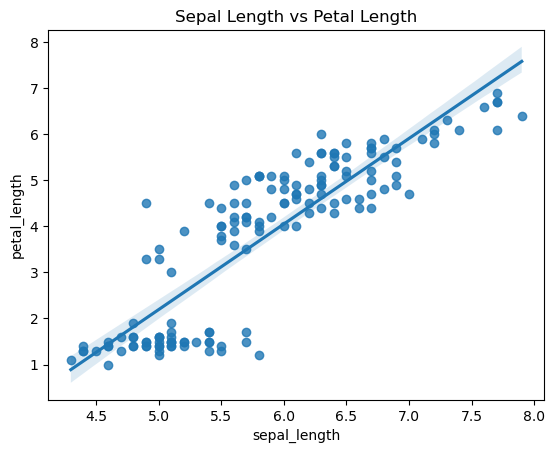

In [49]:

sns.regplot(x='sepal_length', y='petal_length', data=df)
plt.title("Sepal Length vs Petal Length")
plt.show()



The relationship is positive.


## 8. Hypothesis Testing – t-Test

In [50]:

setosa = df[df['species'] == 'setosa']['petal_length']
versicolor = df[df['species'] == 'versicolor']['petal_length']

t_stat, p_val = stats.ttest_ind(setosa, versicolor)
t_stat, p_val


(-39.492719391538095, 5.404910513441677e-62)


Since p < 0.05, the null hypothesis is rejected.


## 9. Hypothesis Testing – ANOVA

In [51]:

setosa_pw = df[df['species']=='setosa']['petal_width']
versicolor_pw = df[df['species']=='versicolor']['petal_width']
virginica_pw = df[df['species']=='virginica']['petal_width']

F_stat, p_val = stats.f_oneway(setosa_pw, versicolor_pw, virginica_pw)
F_stat, p_val


(960.007146801809, 4.169445839443116e-85)


Petal width differs significantly across species.
